## 1. Encàrrec de productora
<p><img src="https://cdn.pixabay.com/photo/2018/10/09/00/21/netflix-3733812_960_720.jpg" alt="foto pelicula"></p>
<p>Una de les productores més importants del mercat ens ha demant fer un anàlisis històric abans d'invertir en una nova pel·lìcula.</p>
<p>Haurem de donar repsposta a diferents preguntes com: </p>

*   La popularitat de les pel·lícules han disminuït durant els anys
*   Quins gènere tenen millor valoracions
*   Les pel·lícules que ofereixen un millor benefici proporcional son les de més pressupost
*   Quins gèneres ofereixen més benefici.
*   Proposa una idea de pel·lìcula
*   Surt a compte fer una segona part?

<p>Per realitzar aquest anàlisis disposem dels següents set de dades:.</p>

*  movies.p: pel·lìcula data i espectadors
*   movie_to_genres.p: gènere de cada pel·lìcula
*   financial.p: dades econòmiques de cada pel·lìcula
*   sequels.p: relació de les pelìcules i les seves sequeles.
*   ratings.p: valoració de les pel·lìcules






---



## Anàlisis de la popularitat

L'empresa creu que durant els darrers anys les pel·lícules tenen menys popularitat. Vol que ho comprovem gràficament

Primer de tot importarem el nostre dataset i analitzarem les seves dades bàsiques ¿Quina es la popularitat mitja i la més alta?

In [180]:
import pandas as pd
import numpy as np

actors_data = pd.read_csv('actors_movies.csv')
financials_data = pd.read_pickle('financials.p')
genres_data = pd.read_pickle('movie_to_genres.p')
movies_data = pd.read_pickle('movies.p')
ratings_data = pd.read_pickle('ratings.p')
sequels_data = pd.read_pickle('sequels.p')

movies_data.head()
print("Popularitat mitjana:", movies_data['popularity'].mean())
print("Popularitat més alta:", movies_data['popularity'].max())

Popularitat mitjana: 21.492300588174057
Popularitat més alta: 875.581305


Necessitem treballar amb el camp release_date com a datatime, així que transformem la columna i ho comprovem. ¿De quin fins a quin any tenim dades?

In [181]:
movies_data['release_date'] = pd.to_datetime(movies_data['release_date'])

print(movies_data['release_date'].min())
print(movies_data['release_date'].max())

1916-09-04 00:00:00
2017-02-03 00:00:00


L'empresa considera que els gustos han canviat molt durant els últims anys, aixi que nomès l'interessen les dades desde el 2010. ¿De cuàntes dades disposem? ¿De cuàntes dades disposem?

In [182]:
movies_recent = movies_data[movies_data['release_date'].dt.year >= 2010]

print(f"Disposem de {movies_data.shape[0]} dades, {movies_recent.shape[0]} de les quals són de després del 2010")

Disposem de 4803 dades, 1446 de les quals són de després del 2010


Pasem a mostrar la linea temporal de com ha variat la popularitat durant els darrers anys.

<Axes: xlabel='release_date'>

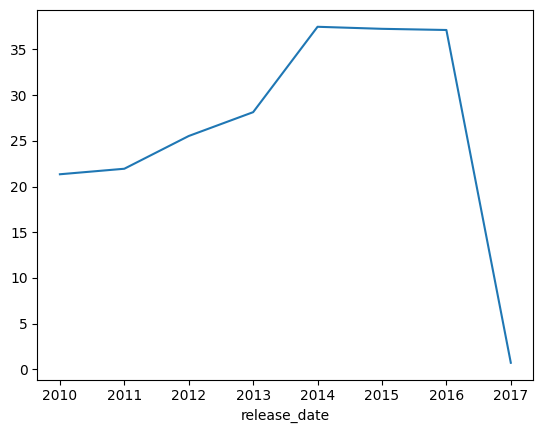

In [183]:
movies_popularity_by_year = movies_recent.groupby(movies_recent['release_date'].dt.year)['popularity'].mean()

movies_popularity_by_year.plot(kind='line')

¿Què passa al 2017, quin és el motiu? Igualment aquesta devadalla és molt extranya, és probalble a que en alguns anys s'hagin realitzat moltes més pel·lícules i que per aquesta raó la mitja sigui molt més alta. Anem a fer el mateix procediment amb la mitja

<Axes: xlabel='release_date'>

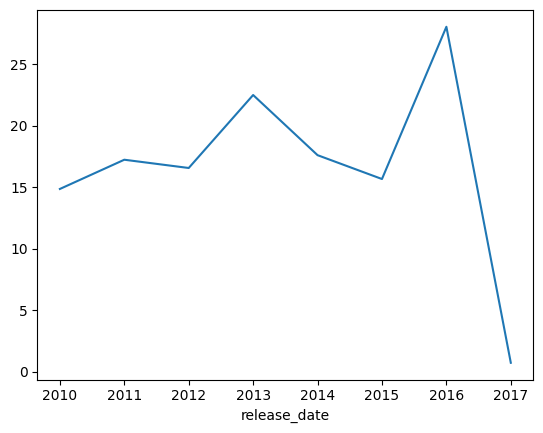

In [184]:
movies_popularity_by_year = movies_recent.groupby(movies_recent['release_date'].dt.year)['popularity'].median()

movies_popularity_by_year.plot(kind='line')

### Resposta 1. Estan perdent popularitat les pel·lìcules?

No, però sembla que hi ha hagut un error amb les dades de l'any 2017. De fet, estan pujant en popularitat.
---



## Anàlisis del rating

Un cop decidit que val la pena realitzar una pel·lìcula, haurem de valorar de quina gènere val la pena en funció de la seva valoració. Primer de tot mostrarem la puntuació mitja de les pel·lícules i les 10 pel·lìcules més valorades. Mostra únicament el nom i el títol de la pel·lìcula ( i el index que surt per defecte)

In [185]:
from functools import reduce

# List of dataframes
dfs = [financials_data, movies_data, ratings_data, sequels_data]

# Merge all dataframes on the 'id' column
all_data = reduce(lambda left, right: pd.merge(left, right, on='id', how='outer'), dfs)

# Median rating of all movies
mean_rating = all_data['vote_average'].mean()

print("Puntuació mitja:", mean_rating)

# Get the top 10 movies
top_movies = all_data.sort_values(all_data['vote_average'])

6.092171559442016


De les pel·lìcules que ens interessa pel nostre anàlisis ( més de 60k de popularitat i més de 2000 valoracions) obtindrem el seu gènere per mostra gràficament la mitja per gènere.

¿Quin és el motiu que els tamany dels dataset siguin diferents?

¿Quins son el tres gèneres amb millor valoració?



---



## Anàlisis econòmic

Observa el dataset financial i els seus estadìstics bàsics. ¿Quin és el pressupost i els ingressos promig?¿Sembla rentable fer una pel·lìcula?

Mostra la distribució (histograma) del pressupost de les pel·lícules. ¿La majoria de pel·lìcules son de baix o alt pressupost?

Más de la mitad de peliculas tienen un presupuesto entre 0 y 50 millones.

Volem mostrar ( nom inclòs) les pel·lìcules les 5 pel·lícules mès profitosses i les 5 més deficitàries de la historia.

No tenim clar si és convenient realitzar una pel·lícula d'alt o baix pressupost, per aquesta raó anem a comparar si existeix una correlació entre el pressupost i el pro_profit guanyat. Podriem mostra una matriu de correlació, pero preferim extreu conclusions visuals a través d'un scatter plot. Et dona la sensació que si s'inverteixen més diner la proporció de benefici és més gran?

En la mateixa gràfica anem incloure les valoracions de les pel·lìcules, aparentment imaginem que les pel·lìcules que han tingut bona acollida son les que mé beneficis han aportat. Veient la gràfica creada sembla certa aquesta afirmaciò?

Finalment per determinar quina tipus de pel·lìcula realitzarem visualitzarem els gèneres que ofereixen millor relació en quant a proporció de benefici. Mirant l'apartat anterior i aquest, quin seria els gèneres de la teva pel·lìcula? Fica imagina i proposa una temàtica.

## 'Segundas partes no son buenas'

La nostra pel·lìcula ha tingut molt bona acollida tant que estem valorant la possibilitat de realitzar una segona part. Existeix la idea de que les seqüeles son sempre pitjors. Mostra la diferència promig entre les pel·lìcules i les seves seqüeles i les 5 pel·lìcules on les seves continuacions han millorat mès.

In [186]:
# mostrem dataset

# Elimina files que no tenen sequel


# comprova que no hi ha NA


# join amb movies per obtenir noms de original i de sequels



# simplifiquem per quedar-nos únicament amb id_original, titol_original, id_sequel, titol_sequel



In [187]:
# Merge per duplicat per obentenir les valoracions


# creem nova columna amb la diferenta valoracació sequel i original


#mostre mitja



In [188]:
# Mostra les 5 millor sequeles en comparació a la seva predecesora



---



## UPGRADE - CASTING


A partir del dataset actors, fes l'anàlisis que consideris adient per escollir els nostres actors/actrius